Shape dataset : (157, 30)


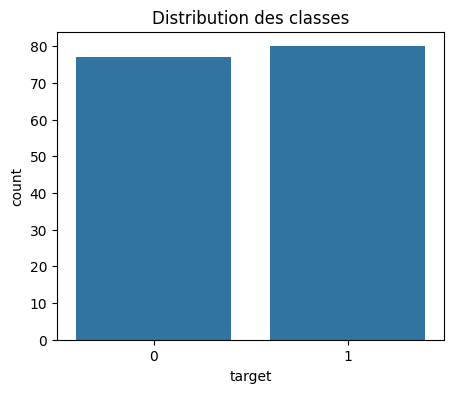


Accuracy TRAIN : 0.968
Accuracy TEST  : 0.90625



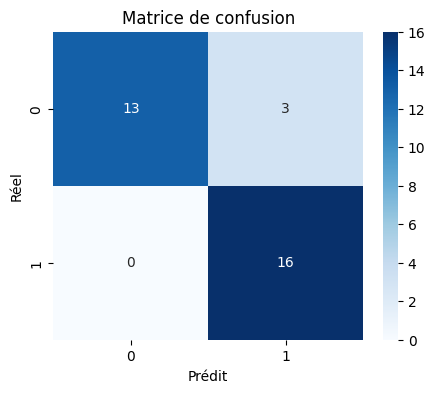


Classification report :

              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.84      1.00      0.91        16

    accuracy                           0.91        32
   macro avg       0.92      0.91      0.91        32
weighted avg       0.92      0.91      0.91        32



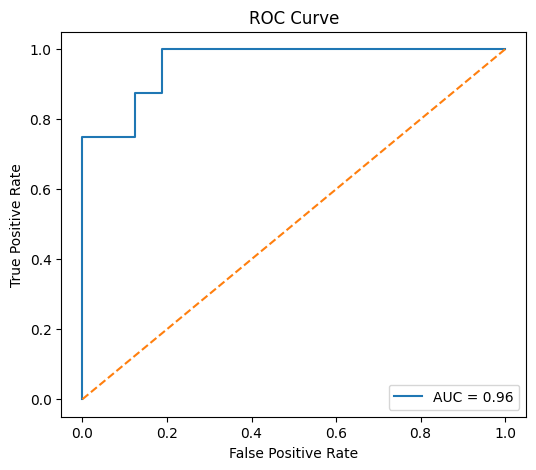

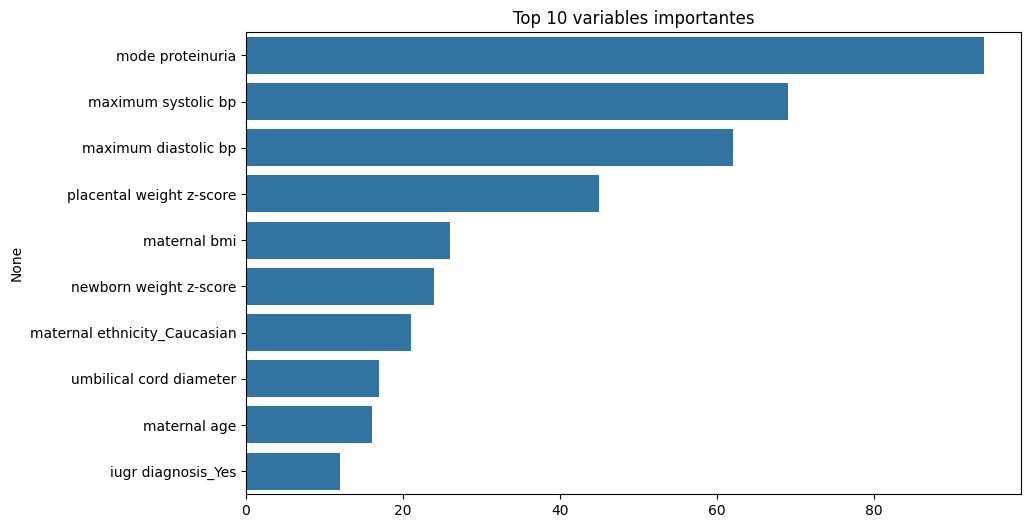

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


df = pd.read_excel("donnees_pretraitees.xlsx")

print("Shape dataset :", df.shape)

# ==============================
# 3. NETTOYAGE
# ==============================
df = df.replace(',', '.', regex=True)

for col in df.columns:
    try:
        df[col] = df[col].astype(float)
    except:
        pass

# ==============================
# 4. TARGET
# ==============================
df["diagnosis"] = df["diagnosis"].astype(str).str.strip().str.lower()

df["target"] = df["diagnosis"].map({
    "pe": 1,
    "non-pe": 0
})

df = df.dropna(subset=["target"])

# ==============================
# 5. SPLIT FEATURES / TARGET
# ==============================
X = df.drop(columns=["target", "diagnosis"])
y = df["target"]

# ==============================
# 6. VISUALISATION 1 - CLASSES
# ==============================
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Distribution des classes")
plt.show()

# ==============================
# 7. TRAIN / TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# 8. ENCODAGE
# ==============================
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ==============================
# 9. DMatrix XGBOOST
# ==============================
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# ==============================
# 10. PARAMÈTRES (ANTI OVERFITTING)
# ==============================
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 4,
    "eta": 0.03,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "gamma": 1,
    "alpha": 0.5,
    "lambda": 1
}

# ==============================
# 11. ENTRAÎNEMENT (SANS LOGS)
# ==============================
evals = [(dtrain, "train"), (dtest, "test")]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=30,
    verbose_eval=False   # 👈 SUPPRESSION DES LOGS
)

# ==============================
# 12. PRÉDICTIONS
# ==============================
train_pred_prob = model.predict(dtrain)
test_pred_prob = model.predict(dtest)

train_pred = (train_pred_prob > 0.5).astype(int)
test_pred = (test_pred_prob > 0.5).astype(int)

# ==============================
# 13. ACCURACY TRAIN / TEST
# ==============================
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\n====================")
print("Accuracy TRAIN :", train_acc)
print("Accuracy TEST  :", test_acc)
print("====================\n")

# ==============================
# 14. MATRICE DE CONFUSION
# ==============================
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, test_pred),
            annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# ==============================
# 15. CLASSIFICATION REPORT
# ==============================
print("\nClassification report :\n")
print(classification_report(y_test, test_pred))

# ==============================
# 16. ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test, test_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ==============================
# 17. FEATURE IMPORTANCE
# ==============================
importance = model.get_score(importance_type='weight')
importance = pd.Series(importance).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance.values[:10], y=importance.index[:10])
plt.title("Top 10 variables importantes")
plt.show()

# ==============================
# 18. LOSS CURVE (TRAIN VS TEST)
# ==============================
results = model.evals_result()

plt.figure(figsize=(8,5))
plt.plot(results["train"]["logloss"], label="Train Loss")
plt.plot(results["test"]["logloss"], label="Test Loss")
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.legend()
plt.show()